# Visualize chuỗi Himawari-9 B13 trên Việt Nam

Notebook này **chỉ đọc và hiển thị** dữ liệu `.DAT` đã được tạo bởi `download.ipynb`. Mỗi timestamp đủ các segment `S03–S05` được vẽ thành một subplot riêng.

In [1]:
%pip install -q satpy pyresample matplotlib cartopy shapely

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import sys
import warnings

import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
from pyresample import create_area_def
from satpy import Scene
from shapely import union_all

USE_GOOGLE_DRIVE = False
DRIVE_DATA_ROOT = Path(
    "/content/drive/MyDrive/Rainfall_Nowcasting/Himawari"
)
SEGMENTS = ["03", "04", "05"]
VIETNAM_BBOX = (102.0, 8.0, 110.0, 24.5)
TIMELINE_COLUMNS = 8
COLOR_LIMITS_K = (190, 310)

if "google.colab" in sys.modules:
    if USE_GOOGLE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        DATA_ROOT = DRIVE_DATA_ROOT
    else:
        DATA_ROOT = Path("/content/himawari")
else:
    local_candidates = [
        Path("Himawari/data/himawari"),
        Path("himawari"),
    ]
    DATA_ROOT = next(
        (path for path in local_candidates if path.is_dir()),
        local_candidates[0],
    )

DAT_DIR = DATA_ROOT / "dat"
OUTPUT_IMAGE = DATA_ROOT / "b13_timeline.png"
FILE_PATTERN = re.compile(
    r"^HS_H09_(?P<date>\d{8})_(?P<time>\d{4})_"
    r"B13_FLDK_R20_S(?P<segment>\d{2})10\.DAT$"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in log",
    category=RuntimeWarning,
)
print("DAT_DIR:", DAT_DIR.resolve())

DAT_DIR: D:\Rainfall_Nowcasting\Himawari\data\himawari\dat


In [3]:
required_segments = set(SEGMENTS)
files_by_slot: dict[str, dict[str, Path]] = {}
for path in sorted(DAT_DIR.rglob("HS_H09_*_B13_FLDK_R20_S*10.DAT")):
    match = FILE_PATTERN.match(path.name)
    if match is None:
        continue
    segment = match.group("segment")
    if segment not in required_segments:
        continue
    slot = f'{match.group("date")}_{match.group("time")}'
    files_by_slot.setdefault(slot, {})[segment] = path

complete_slots = [
    (slot, segment_files)
    for slot, segment_files in sorted(files_by_slot.items())
    if required_segments.issubset(segment_files)
]
incomplete_slots = [
    slot
    for slot, segment_files in sorted(files_by_slot.items())
    if not required_segments.issubset(segment_files)
]
if not complete_slots:
    raise FileNotFoundError(
        f"Không có timestamp B13 nào đủ segment {SEGMENTS} trong {DAT_DIR}"
    )
print(f"Tìm thấy {len(complete_slots)} timestamp B13 hoàn chỉnh.")
if incomplete_slots:
    print("Bỏ qua timestamp thiếu segment:", incomplete_slots)

Tìm thấy 48 timestamp B13 hoàn chỉnh.


In [4]:
vietnam_area = create_area_def(
    "vietnam_latlon",
    {"proj": "longlat", "datum": "WGS84"},
    area_extent=VIETNAM_BBOX,
    resolution=(0.02, 0.02),
    units="degrees",
)
countries_path = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_0_countries",
)
vietnam_parts = [
    record.geometry
    for record in shpreader.Reader(countries_path).records()
    if record.attributes.get("ADM0_A3") == "VNM"
    or record.attributes.get("ADMIN") == "Vietnam"
]
if not vietnam_parts:
    raise RuntimeError("Không tìm thấy polygon Việt Nam trong Natural Earth")
vietnam_geometry = union_all(vietnam_parts)


def draw_vietnam_boundary(axis, color: str = "red") -> None:
    polygons = (
        vietnam_geometry.geoms
        if vietnam_geometry.geom_type == "MultiPolygon"
        else [vietnam_geometry]
    )
    for polygon in polygons:
        longitude, latitude = polygon.exterior.xy
        axis.plot(longitude, latitude, color=color, linewidth=0.8, zorder=5)

Đã hiển thị 48 timestamp; lưới 6 x 8.
Đã lưu: D:\Rainfall_Nowcasting\Himawari\data\himawari\b13_timeline.png


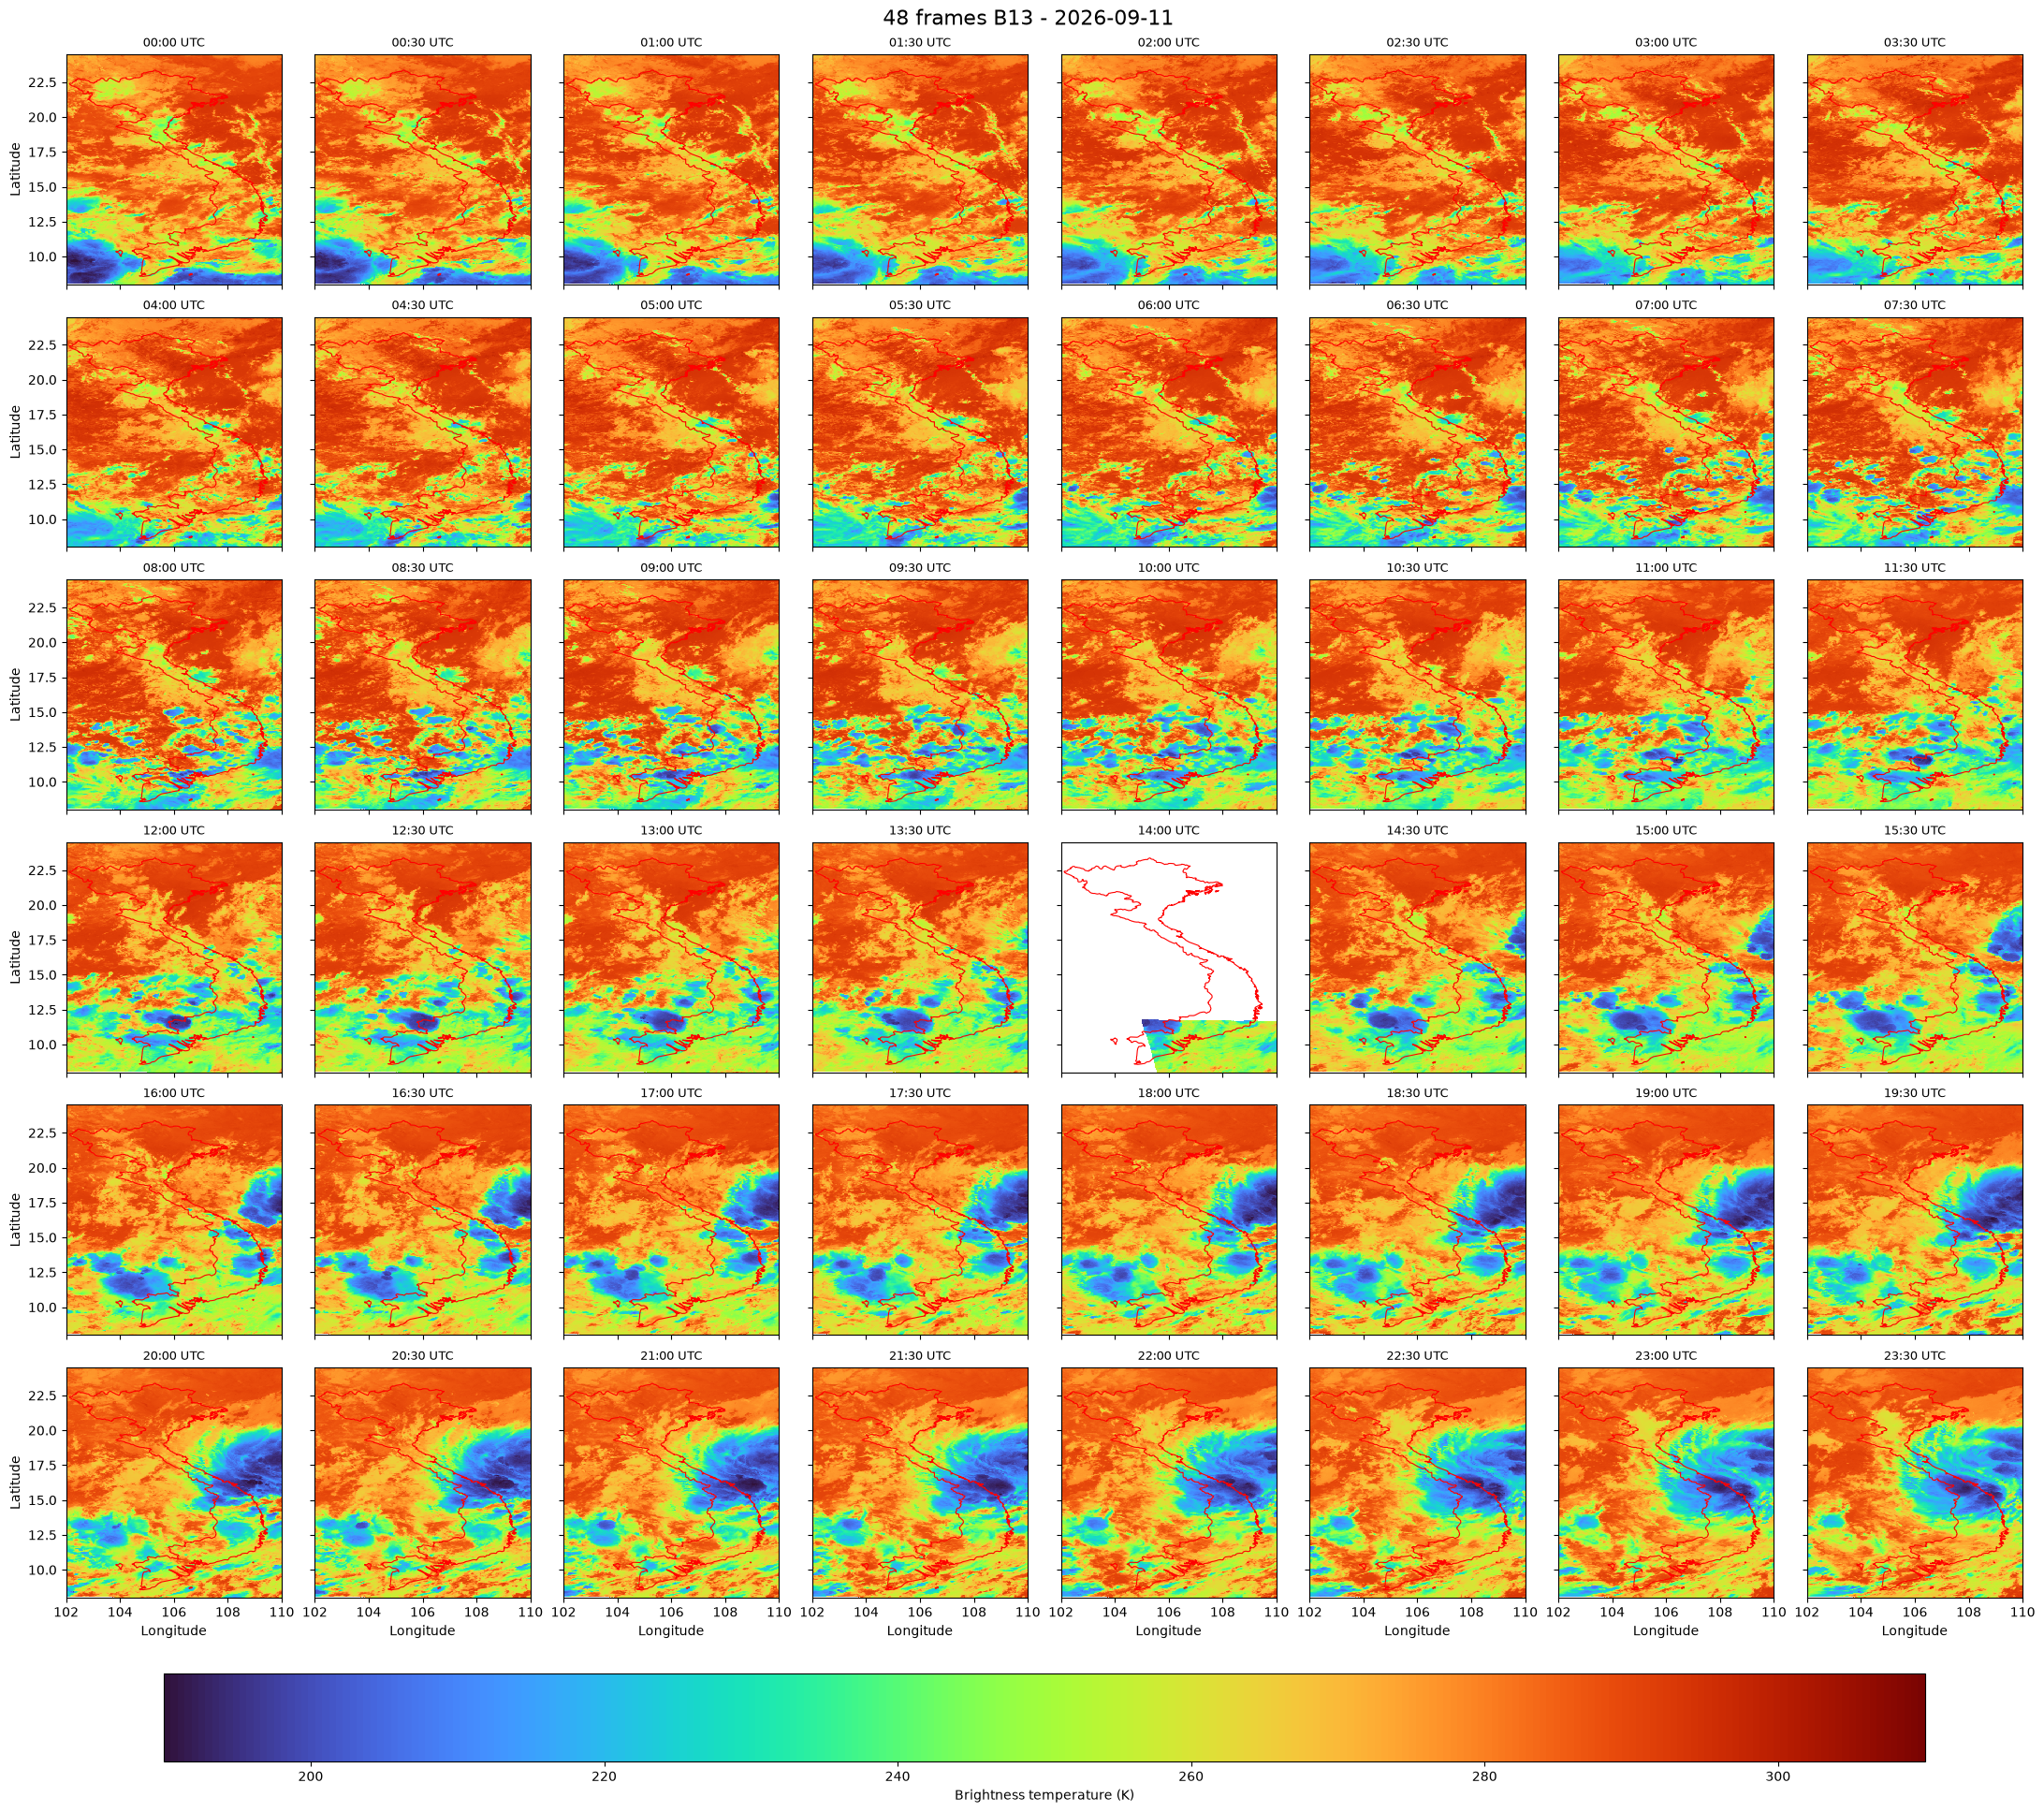

In [5]:
def load_b13_vietnam(segment_files: dict[str, Path]):
    scene = Scene(
        reader="ahi_hsd",
        filenames=[str(segment_files[segment]) for segment in SEGMENTS],
    )
    scene.load(["B13"], calibration="brightness_temperature")
    cropped_scene = scene.crop(ll_bbox=VIETNAM_BBOX)
    resample_scene = Scene()
    resample_scene["B13"] = cropped_scene["B13"]
    latlon_scene = resample_scene.resample(
        vietnam_area,
        datasets=["B13"],
        resampler="nearest",
        unload=False,
    )
    return latlon_scene["B13"].rename("B13").compute()


frame_count = len(complete_slots)
column_count = min(TIMELINE_COLUMNS, frame_count)
row_count = (frame_count + column_count - 1) // column_count
figure, axes = plt.subplots(
    nrows=row_count,
    ncols=column_count,
    figsize=(2.7 * column_count, 3.2 * row_count),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)
axes_flat = axes.ravel()
image = None
lon_min, lat_min, lon_max, lat_max = VIETNAM_BBOX
dates = {slot[:8] for slot, _ in complete_slots}
is_single_day = len(dates) == 1
colormap = plt.colormaps["turbo"].copy()
colormap.set_bad("white")
for axis, (slot, segment_files) in zip(axes_flat, complete_slots):
    data = load_b13_vietnam(segment_files)
    image = data.plot.imshow(
        ax=axis,
        cmap=colormap,
        vmin=COLOR_LIMITS_K[0],
        vmax=COLOR_LIMITS_K[1],
        add_colorbar=False,
    )
    draw_vietnam_boundary(axis)
    axis.set_xlim(lon_min, lon_max)
    axis.set_ylim(lat_min, lat_max)
    if is_single_day:
        title = f"{slot[9:11]}:{slot[11:13]} UTC"
    else:
        title = (
            f"{slot[:4]}-{slot[4:6]}-{slot[6:8]} "
            f"{slot[9:11]}:{slot[11:13]} UTC"
        )
    axis.set_title(title, fontsize=9)
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.label_outer()
for axis in axes_flat[frame_count:]:
    axis.set_visible(False)
colorbar = figure.colorbar(
    image,
    ax=axes_flat.tolist(),
    orientation="horizontal",
    shrink=0.9,
    pad=0.02,
)
colorbar.set_label("Brightness temperature (K)")
if is_single_day:
    date = next(iter(dates))
    figure_title = (
        f"{frame_count} frames B13 - "
        f"{date[:4]}-{date[4:6]}-{date[6:8]}"
    )
else:
    figure_title = f"{frame_count} frames Himawari-9 B13"
figure.suptitle(figure_title, fontsize=16)
figure.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches="tight")
print(f"Đã hiển thị {frame_count} timestamp; lưới {row_count} x {column_count}.")
print("Đã lưu:", OUTPUT_IMAGE.resolve())
plt.show()